In [67]:
# Some package imports
import sys
import pickle
from pathlib import Path

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

# Load and set up results

In [68]:
CURRENT_DIR = Path.cwd().resolve()
PROJECT_ROOT = CURRENT_DIR.parent
RUNNING_DIR = PROJECT_ROOT / "running"
SRC_DIR = PROJECT_ROOT / "src"
OUTPUTS_DIR = PROJECT_ROOT / "outputs"

for path in [str(PROJECT_ROOT), str(RUNNING_DIR), str(SRC_DIR)]:
    if path not in sys.path:
        sys.path.insert(0, path)

def load_result_pickle(path: str | Path):
    path = Path(path)
    with path.open("rb") as f:
        return pickle.load(f)

def load_all_result_pickles(results_dir: str | Path):
    results_dir = Path(results_dir)
    pickle_paths = sorted(p for p in results_dir.rglob("simulation_result_run_*.pkl") if "_qtable" not in p.name)
    if not pickle_paths:
        raise FileNotFoundError(f"No result pickle files were found under: {results_dir}")
    return [load_result_pickle(path) for path in pickle_paths], pickle_paths

def get_most_recent_batch_dir(outputs_dir: str | Path) -> Path:
    """
    Return the most recently modified batch folder inside BigProject/outputs. Assumes each simulation batch is stored in its own subfolder (timestamp folder).
    """
    outputs_dir = Path(outputs_dir)

    if not outputs_dir.exists():
        raise FileNotFoundError(f"Outputs directory does not exist: {outputs_dir}")

    subdirs = [p for p in outputs_dir.iterdir() if p.is_dir() and p.name != "for_r"]

    if not subdirs:
        raise FileNotFoundError(f"No batch subfolders were found inside: {outputs_dir}")

    return max(subdirs, key=lambda p: p.stat().st_mtime)

# Option 1: manually specify a batch folder
# results_dir = OUTPUTS_DIR / "2026-05-26_19-10-32" 

# Option 2: automatically use the most recent batch folder
results_dir = get_most_recent_batch_dir(OUTPUTS_DIR)
print("Using results folder:", results_dir)

results_list, pickle_paths = load_all_result_pickles(results_dir)
print("Loaded result files:", len(results_list))

condition_counts = (pd.DataFrame([{"structure": r.metadata.get("structure"), "leader_style": r.metadata.get("leader_style")} for r in results_list]).value_counts().reset_index(name="n_runs"))
display(condition_counts)

Using results folder: \\lightning.bu.binghamton.edu\WISE\sescott1\Masters\523\Emotion-Contagion\BigProject\outputs\2026-06-02_14-17-31
Loaded result files: 360


,structure,leader_style,n_runs
0,community,Free,20
1,community,High_Fully_Constrained,20
2,community,High_Initially_Constrained,20
3,community,Low_Fully_Constrained,20
4,community,Low_Initially_Constrained,20
5,community,No_Intervention,20
6,core_periphery,Free,20
7,core_periphery,High_Fully_Constrained,20
8,core_periphery,High_Initially_Constrained,20
9,core_periphery,Low_Fully_Constrained,20


### What the objects look like (give this to the LLM of your choice when asking for analysis help, so they know how results are structured)
@dataclass
class SimulationResults:
    run_id: Any                                  # scalar
    seed: int                                    # scalar

    state: SimulationState                       # final state object
      state.agents: List[Dict[str, Any]]         # [agent]
      state.leader_index: int                    # scalar
      state.intimacy_matrix: np.ndarray          # [agent, agent]
      state.assignments: np.ndarray | None       # [agent]
      state.time: int                            # scalar
      state.metadata: Dict[str, Any]             # config / run metadata

    initial_conditions: pd.DataFrame             # [agent, variable]
    emotion_history: List[List[float]]           # [t_state][agent]; t_state = 0 is the initial state before timestep 0, len(emotion_history) = max_iterations + 1
    avg_emotion_history: List[float]             # [t], member-only avg emotion per timestep, len(avg_emotion_history) = max_iterations
    buddies_per_timestep: List[List[Tuple[int, int]]]   # [t][interaction_pair]; each pair is (i, j) in full-agent indexing, member-member only
    interactions_per_timestep: List[int]         # [t]; number of member-member interactions at each timestep
    intervention_timesteps: List[int]            # [t_intervention]; sparse list of timesteps where leader intervened
    absorption_history: List[Dict[Tuple[int, int], float]]   # [t][(i, j)] cumulative absorption; cumulative absorption/change dictionary after each timestep
    final_absorption_dict: Dict[Tuple[int, int], float]      # [(i, j)] final cumulative absorption
    metadata: Dict[str, Any]                     # run-level metadata / parameters (like: network specifications, leader_style, condition_name, population_size, max_iterations, adaptive_intimacy)
    leader_summary: Dict[str, Any]               # small final leader summary (style, leader_index, leader_emotion, emotionManagementAbility, interventionThreshold, dampening)

batch = {
    "results": List[SimulationResults],          # [run]
    "summary_df": pd.DataFrame | None,           # [run, summary_variable]
    "output_dir": Path,                          # scalar
    "summary_path": Path | None,                 # scalar
    "conditions_used": List[Dict[str, Any]]     # [condition]
}

In [69]:
# Build tables
def get_condition_key(results):
    return (results.metadata.get("structure"), results.metadata.get("leader_style"))

def build_avg_emotion_df(results_list):
    rows = []
    for results in results_list:
        structure = results.metadata.get("structure")
        leader_style = results.metadata.get("leader_style")
        condition_name = results.metadata.get("condition_name")

        for t, avg_emotion in enumerate(results.avg_emotion_history):
            rows.append({
                "run_id": results.run_id,
                "seed": results.seed,
                "condition_name": condition_name,
                "structure": structure,
                "leader_style": leader_style,
                "time": t,
                "avg_member_emotion": avg_emotion
            })
    return pd.DataFrame(rows)

def build_intervention_frequency_df(results_list):
    rows = []
    for results in results_list:
        structure = results.metadata.get("structure")
        leader_style = results.metadata.get("leader_style")
        condition_name = results.metadata.get("condition_name")

        n_t = len(results.avg_emotion_history)
        intervention_log = (results.intervention_log if results.intervention_log is not None else {})
        for t in range(n_t):
            action = intervention_log.get(t, 0)
            rows.append({
                "run_id": results.run_id,
                "seed": results.seed,
                "condition_name": condition_name,
                "structure": structure,
                "leader_style": leader_style,
                "time": t,
                "action": action, # raw action strength
                "intervened": int(action != 0),   # convenience binary version

                # one-hot indicators
                "action_no": int(action == 0),
                "action_weak": int(action == 1),
                "action_medium": int(action == 2),
                "action_strong": int(action == 3),
            })
    return pd.DataFrame(rows)

def build_intervention_summary_df(results_list):
    rows = []
    for results in results_list:
        intervention_log = (results.intervention_log if results.intervention_log is not None else {})
        intervention_times = sorted(intervention_log.keys())
        actions = list(intervention_log.values())

        rows.append({
            "run_id": results.run_id,
            "seed": results.seed,
            "condition_name": results.metadata.get("condition_name"),
            "structure": results.metadata.get("structure"),
            "leader_style": results.metadata.get("leader_style"),

            # overall intervention info
            "num_interventions": len(intervention_times),
            "first_intervention_time": (intervention_times[0] if intervention_times else np.nan),
            "had_any_intervention": int(len(intervention_times) > 0),

            # strength-specific counts
            "num_weak": sum(a == 1 for a in actions),
            "num_medium": sum(a == 2 for a in actions),
            "num_strong": sum(a == 3 for a in actions),

            # proportions among interventions
            "prop_weak": (np.mean([a == 1 for a in actions]) if actions else np.nan),
            "prop_medium": (np.mean([a == 2 for a in actions]) if actions else np.nan),
            "prop_strong": (np.mean([a == 3 for a in actions]) if actions else np.nan),
        })

    return pd.DataFrame(rows)

def build_intervention_raster_df(results_list):
    rows = []
    for results in results_list:
        intervention_log = (results.intervention_log if results.intervention_log is not None else {})
        for t, action in intervention_log.items():
            rows.append({
                "run_id": results.run_id,
                "seed": results.seed,
                "condition_name": results.metadata.get("condition_name"),
                "structure": results.metadata.get("structure"),
                "leader_style": results.metadata.get("leader_style"),
                "time": t,
                "action": action,
                "action_label": {
                    0: "No",
                    1: "Weak",
                    2: "Medium",
                    3: "Strong",
                }.get(action, str(action))
            })

    return pd.DataFrame(rows)

def build_rl_action_df(results_list):
    rows = []
    for results in results_list:

        if not hasattr(results, "rl_actions"):
            continue

        if results.rl_actions is None:
            continue

        for t, action in enumerate(results.rl_actions):
            rows.append({
                "run_id": results.run_id,
                "seed": results.seed,
                "condition_name": results.metadata.get("condition_name"),
                "structure": results.metadata.get("structure"),
                "leader_style": results.metadata.get("leader_style"),
                "time": t,
                "action": action,
                "intervened": int(action != 0),
            })

    return pd.DataFrame(rows)

def build_rl_quality_df(results_list):
    rows = []
    for results in results_list:

        if not hasattr(results, "rl_quality"):
            continue

        if results.rl_quality is None:
            continue

        for t, quality in enumerate(results.rl_quality):
            rows.append({
                "run_id": results.run_id,
                "seed": results.seed,
                "condition_name": results.metadata.get("condition_name"),
                "structure": results.metadata.get("structure"),
                "leader_style": results.metadata.get("leader_style"),
                "time": t,
                "quality": quality
            })

    return pd.DataFrame(rows)

def build_homophily_df(results_list):
    rows = []
    for results in results_list:

        if not hasattr(results, "homophily_history"):
            continue

        if results.homophily_history is None:
            continue

        for t, value in enumerate(results.homophily_history):
            rows.append({
                "run_id": results.run_id,
                "seed": results.seed,
                "condition_name": results.metadata.get("condition_name"),
                "structure": results.metadata.get("structure"),
                "leader_style": results.metadata.get("leader_style"),
                "time": t,
                "homophily": value,
            })

    return pd.DataFrame(rows)

avg_df = build_avg_emotion_df(results_list)
intervention_freq_df = build_intervention_frequency_df(results_list)
intervention_summary_df = build_intervention_summary_df(results_list)
intervention_raster_df = build_intervention_raster_df(results_list)
rl_action_df = build_rl_action_df(results_list)
rl_quality_df = build_rl_quality_df(results_list)
homophily_df = build_homophily_df(results_list)

avg_df.shape, intervention_summary_df.shape, intervention_freq_df.shape, intervention_raster_df.shape, rl_quality_df.shape, homophily_df.shape

((144000, 7), (360, 14), (144000, 12), (59245, 8), (120300, 7), (144360, 7))

In [70]:
# Helper functions for plotting
structures = ["random", "community", "core_periphery"]
leader_styles = ["No_Intervention", "High_Initially_Constrained", "Low_Initially_Constrained", "High_Fully_Constrained", "Low_Fully_Constrained", "Free"]
styles_pretty = {
    "High_Fully_Constrained": "High Fully",
    "High_Initially_Constrained": "High Initial",
    "Low_Fully_Constrained": "Low Fully",
    "Low_Initially_Constrained": "Low Initial",
    "Free": "Free",
    "No_Intervention": "None"
}

def get_ax(axes, structure, leader_style):
    row = structures.index(structure)
    col = leader_styles.index(leader_style)
    return axes[row, col]

def format_condition_title(structure, leader_style):
    return f"{structure}\n{leader_style}"

def format_condition_pretty_title(structure, leader_style):
    return f"{structure}\n{styles_pretty[leader_style]}"

# Some plotting

### Avg team emotion over time w/ s.d. 1, 2, 3
Shows variability across repititions (the s.d. shading/bands), per condition
- narrower = more similarity across repetitions
- wider = more difference across repetitions
- line goes upward over time → teams tend to improve emotionally
- line stays low/negative → teams remain emotionally worse off
- line rises fast at the beginning → the condition stabilizes/improves the team quickly
- line is noisy or flat with wide band → outcomes are unstable or inconsistent

can be used to compare things like:
- final level of the line
- speed of recovery/improvement
- amount of variability

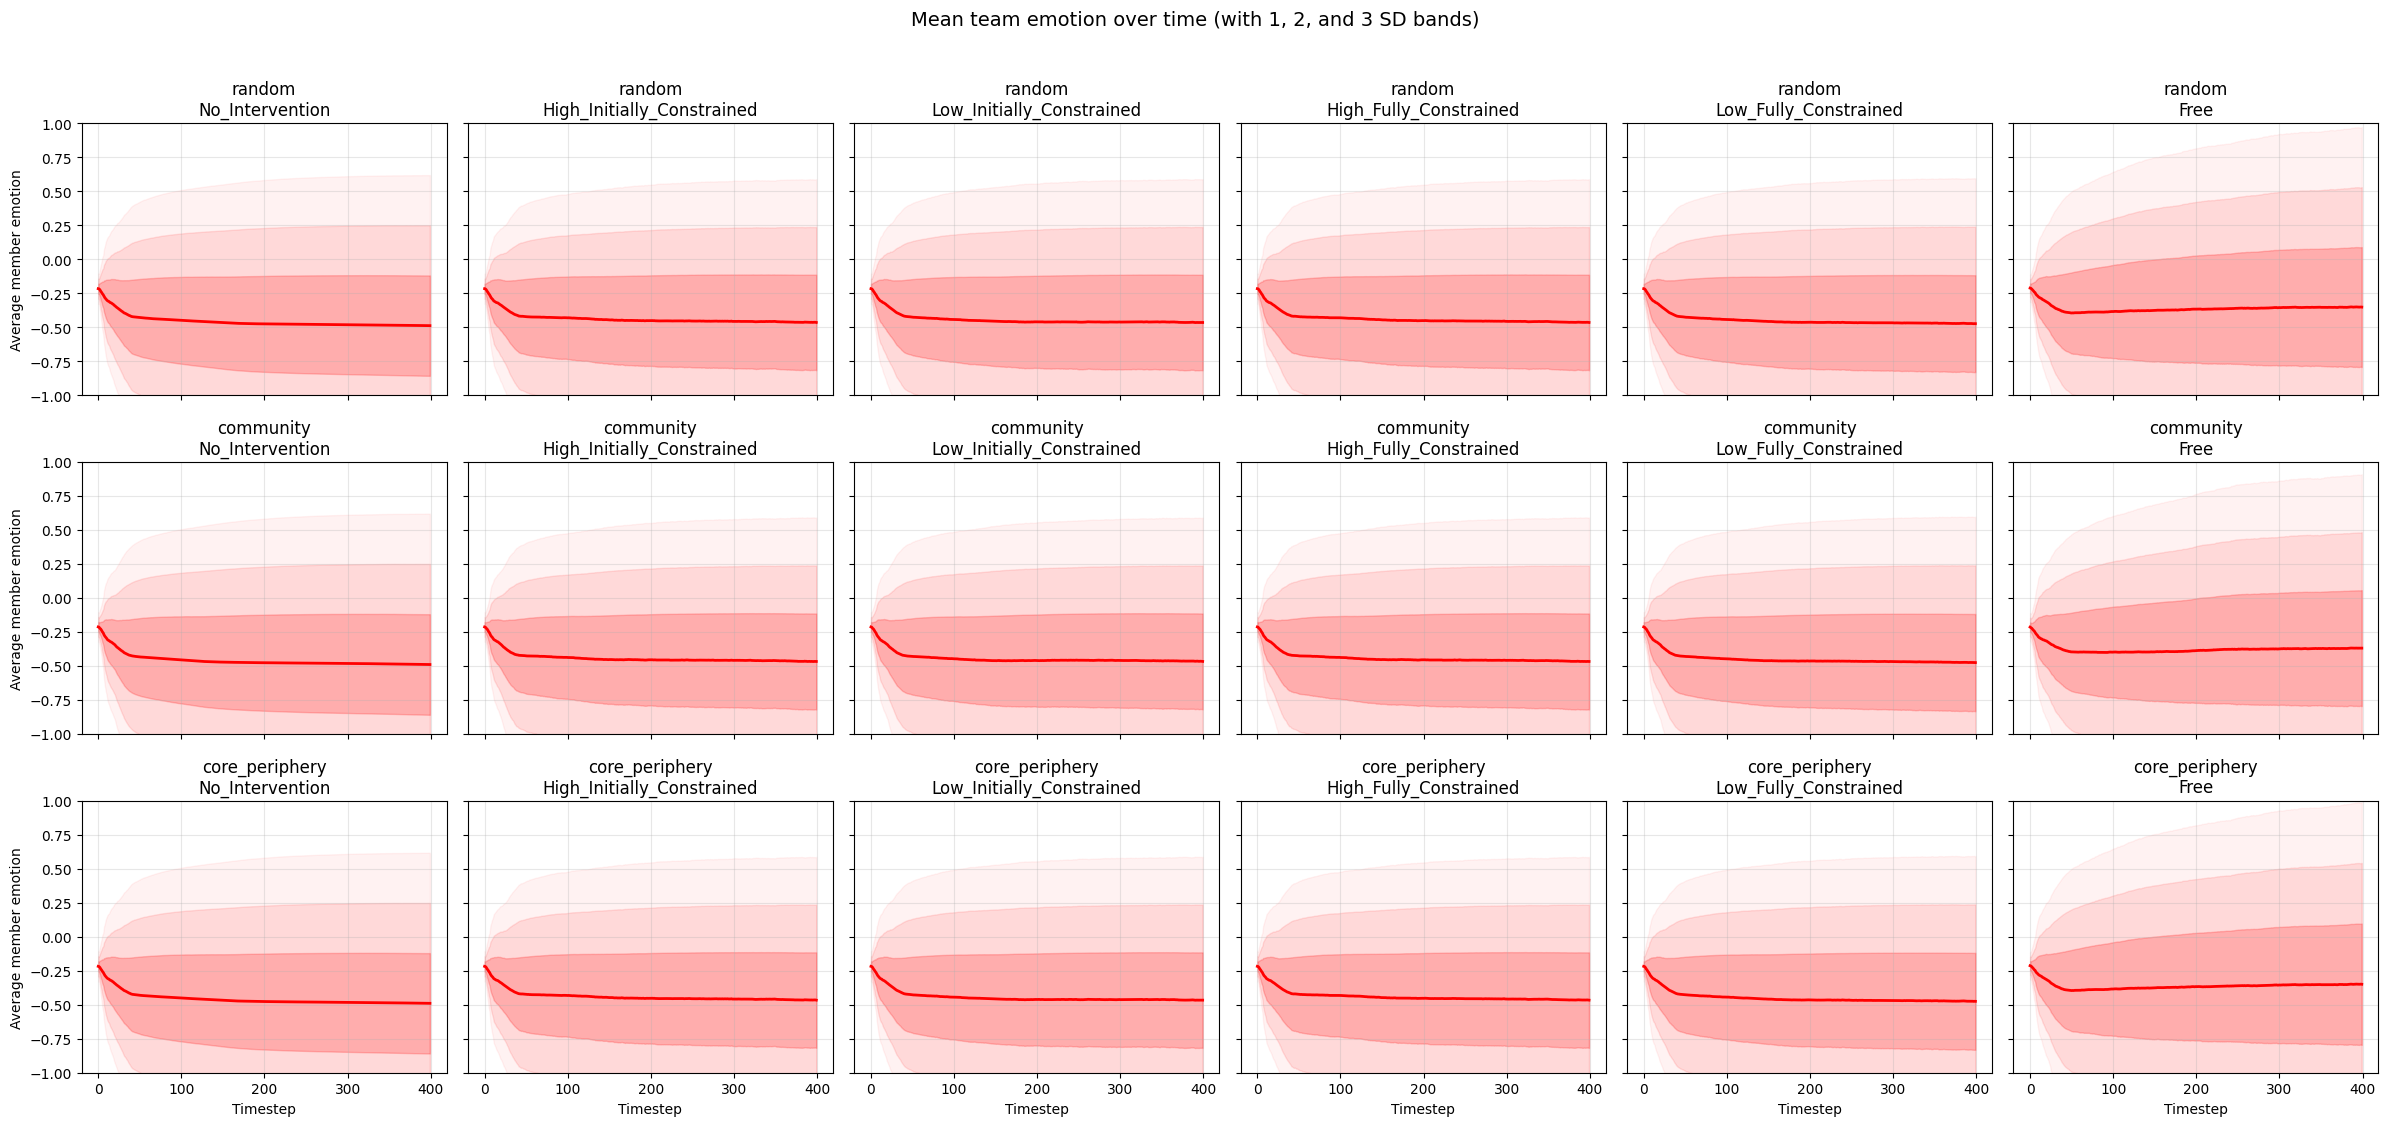

In [71]:
emotion_summary_df = (avg_df.groupby(["structure", "leader_style", "time"], as_index=False).agg(mean_avg_member_emotion=("avg_member_emotion", "mean"), sd_avg_member_emotion=("avg_member_emotion", "std"), n_runs=("avg_member_emotion", "count")))
emotion_summary_df["sd_avg_member_emotion"] = emotion_summary_df["sd_avg_member_emotion"].fillna(0.0)

fig, axes = plt.subplots(len(structures), len(leader_styles), figsize=(24, 11), sharex=True, sharey=True)

for structure in structures:
    for leader_style in leader_styles:
        ax = get_ax(axes, structure, leader_style)
        sub = emotion_summary_df[(emotion_summary_df["structure"] == structure) & (emotion_summary_df["leader_style"] == leader_style)].sort_values("time")

        if not sub.empty:
            x = sub["time"].to_numpy()
            y = sub["mean_avg_member_emotion"].to_numpy()
            s = sub["sd_avg_member_emotion"].to_numpy()

            ax.plot(x, y, color="red", linewidth=2)

            ax.fill_between(x, y - 3*s, y + 3*s, color="red", alpha=0.05)
            ax.fill_between(x, y - 2*s, y + 2*s, color="red", alpha=0.10)
            ax.fill_between(x, y - 1*s, y + 1*s, color="red", alpha=0.20)

        ax.set_title(format_condition_title(structure, leader_style))
        ax.set_ylim(-1, 1)
        ax.grid(True, alpha=0.3)

for ax in axes[-1, :]:
    ax.set_xlabel("Timestep")

for ax in axes[:, 0]:
    ax.set_ylabel("Average member emotion")

fig.suptitle("Mean team emotion over time (with 1, 2, and 3 SD bands)", y=1.02, fontsize=14)

fig.tight_layout()
plt.show()

### Fraction of runs in which an intervention occurred

Can be used from the perspective of: How likely is an intervention at each timestep under a certain condition?

How to interpret values:
- value nearer 1, or spiking → leader intervenes at that timestep a lot across runs
- value nearer 0 → leader almost never intervenes at that timestep
- consistent flatness → a stable fraction of runs had interventions (~ could be read as a leader having a consistent regime)
- that step-like look can be thought of as regime shifts/transitions and persistence

e.g.: 0.5 at timestep 50 means 50% of repetitions had an intervention at timestep 100
      meany grids show timesteps increasing up to around timestep 50 and then either continuing up, spiking, flat

Can be used to compare things like:
- which conditions trigger intervention more reliably ()
- whether leaders intervene earlier or later
- whether timing is tightly clustered or scattered

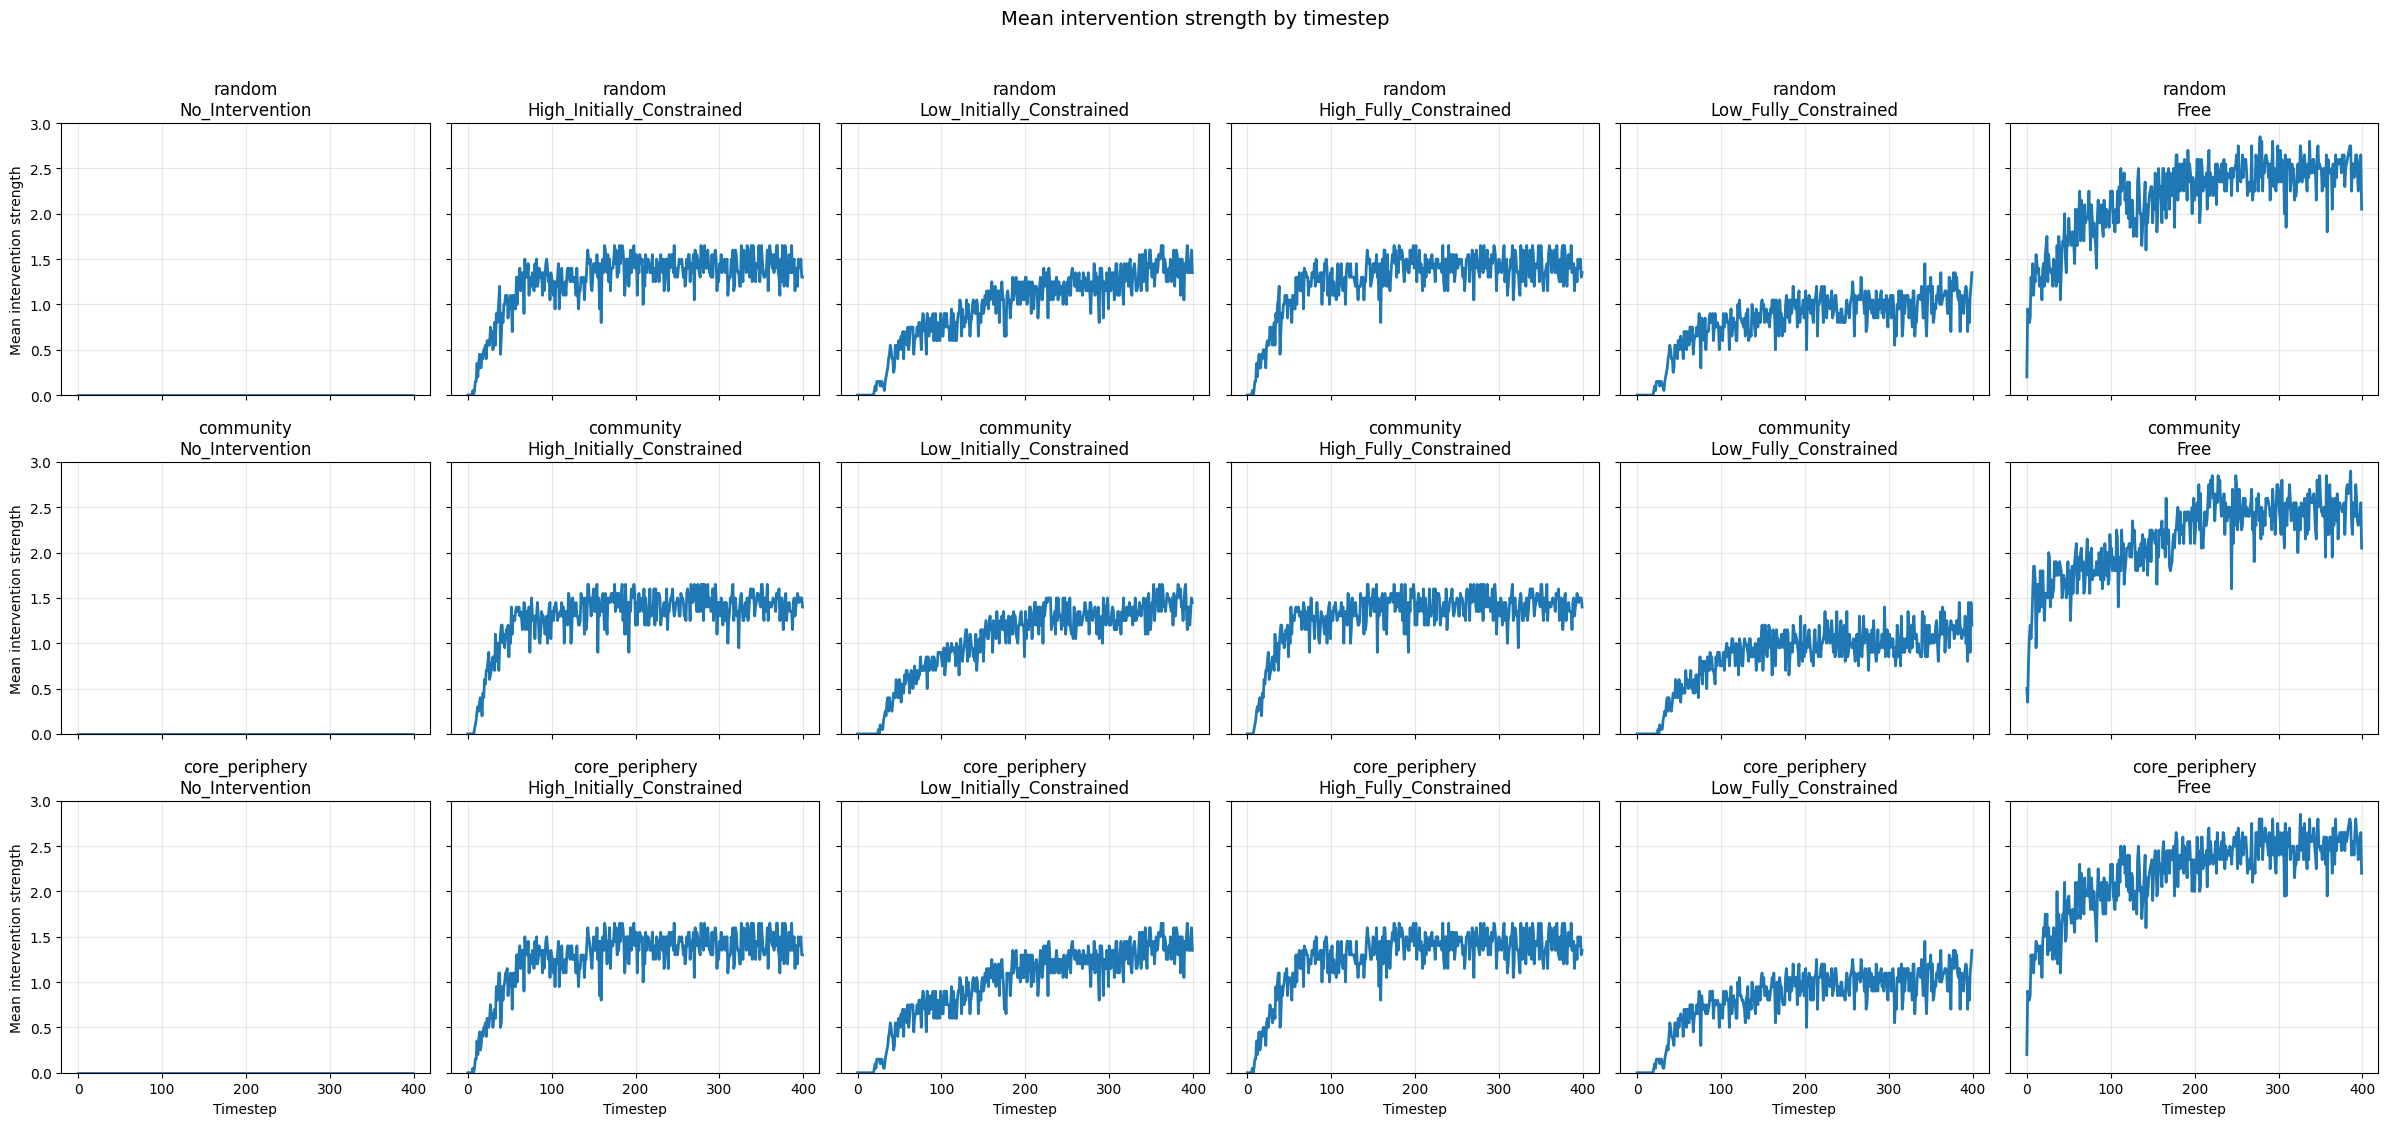

In [72]:
freq_plot_df = (intervention_freq_df.groupby(["structure", "leader_style", "time"], as_index=False)["action"].mean().rename(columns={"action": "mean_intervention_strength"}))

fig, axes = plt.subplots(len(structures), len(leader_styles), figsize=(24, 11), sharex=True, sharey=True)

for structure in structures:
    for leader_style in leader_styles:
        ax = get_ax(axes, structure, leader_style)
        sub = freq_plot_df[(freq_plot_df["structure"] == structure) & (freq_plot_df["leader_style"] == leader_style)]
        if not sub.empty:
            ax.plot(sub["time"], sub["mean_intervention_strength"], linewidth=2)

        ax.set_title(format_condition_title(structure, leader_style))
        ax.set_ylim(0, 3)
        ax.grid(True, alpha=0.3)

for ax in axes[-1, :]:
    ax.set_xlabel("Timestep")

for ax in axes[:, 0]:
    ax.set_ylabel("Mean intervention strength")

fig.suptitle("Mean intervention strength by timestep", y=1.02, fontsize=14)

fig.tight_layout()
plt.show()

#### Table version of the above
- mean_num_interventions: mean number of interventions
- sd_num_interventions: sd of number of interventions
- mean_first_intervention: mean first intervention time
- prop_any_intervention: proportion of runs with any intervention (higher value = higher tendency for intervention to occur across runs)
- n_runs: number of runs/repetitions

In [73]:
intervention_summary_table = (intervention_summary_df.groupby(["structure", "leader_style"], as_index=False).agg(mean_num_interventions=("num_interventions", "mean"), sd_num_interventions=("num_interventions", "std"), mean_first_intervention_time=("first_intervention_time", "mean"), prop_any_intervention=("had_any_intervention", "mean"), n_runs=("run_id", "count"))) 
intervention_summary_table
#intervention_summary_table.sort_values(["structure", "leader_style"])

,structure,leader_style,mean_num_interventions,sd_num_interventions,mean_first_intervention_time,prop_any_intervention,n_runs
0,community,Free,337.10,46.448500,2.250000,1.00,20
1,community,High_Fully_Constrained,189.05,176.845004,31.272727,0.55,20
2,community,High_Initially_Constrained,189.05,176.845004,31.272727,0.55,20
3,community,Low_Fully_Constrained,127.50,151.830758,106.272727,0.55,20
4,community,Low_Initially_Constrained,151.45,154.672651,106.272727,0.55,20
5,community,No_Intervention,0.00,0.000000,NaN,0.00,20
6,core_periphery,Free,343.85,41.156025,2.100000,1.00,20
7,core_periphery,High_Fully_Constrained,185.65,174.185707,34.272727,0.55,20
8,core_periphery,High_Initially_Constrained,185.10,173.649344,34.272727,0.55,20
9,core_periphery,Low_Fully_Constrained,125.95,147.882412,110.454545,0.55,20


### Raster plot of interventions for each run, grouped by condition; one row per run and marks intervention times

A way to see the pattern of interventions

How to interpret:
- One row = one repeition. 
- One mark (|) = one intervention timestep
- Vertical clustering (stacked blocks/marks) → many runs intervene at the same times
- Scattered marks → intervention timing varies
- Dense rows → some runs have many interventions
- Empty rows → some runs had none
- Varying dens + empty rows in a condition = leader's regime varies across repitions/runs (so if leader aspects are held constant, then perhaps something else is going on leading to these differences)

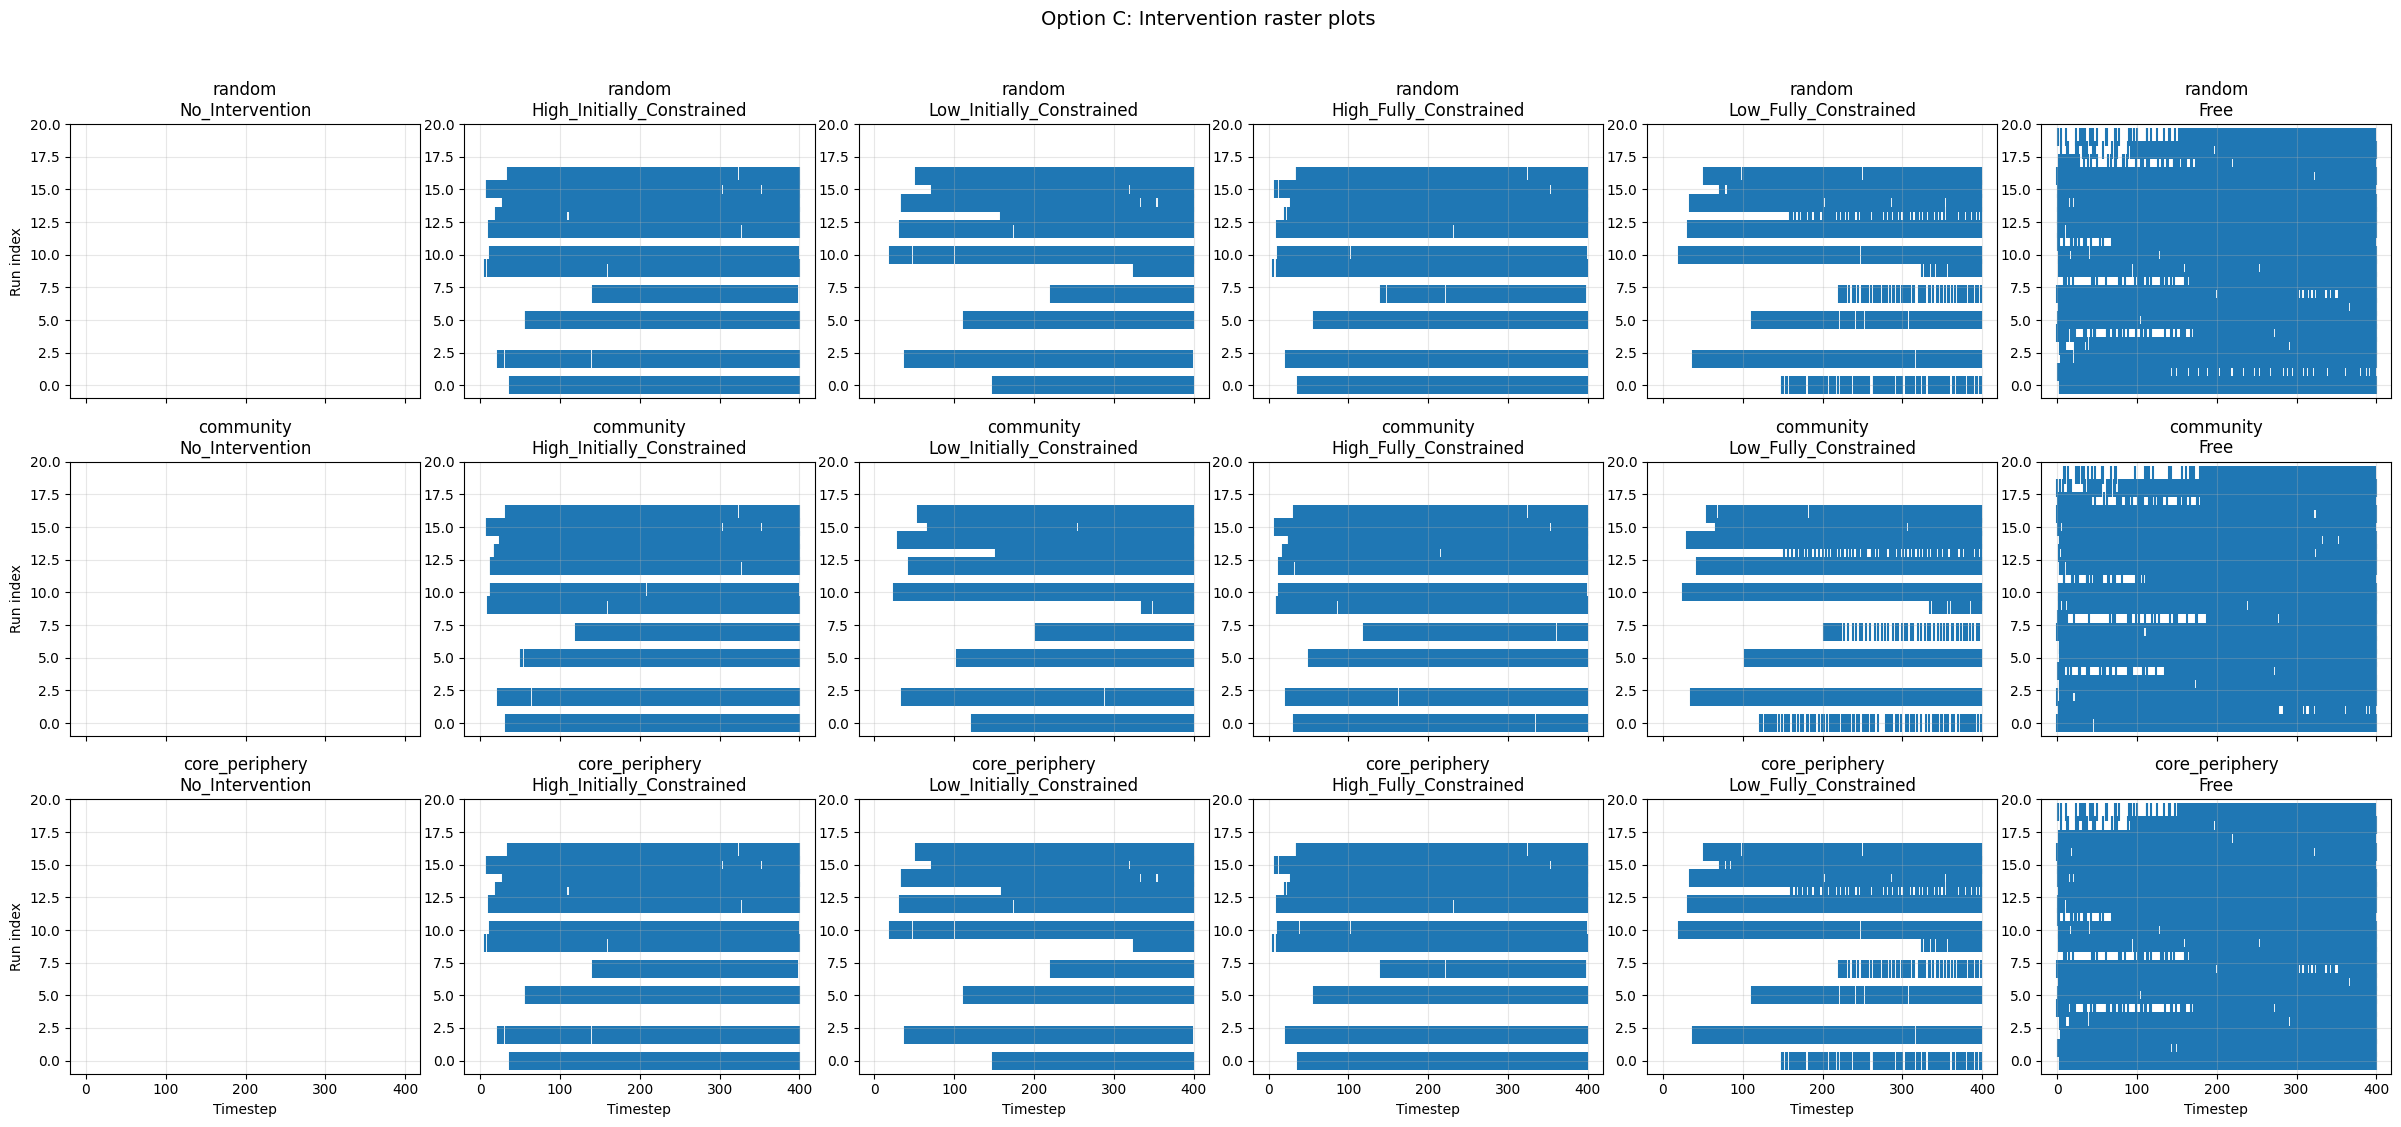

In [74]:
run_order_df = (intervention_summary_df[["run_id", "structure", "leader_style"]].drop_duplicates().sort_values(["structure", "leader_style", "run_id"]))

fig, axes = plt.subplots(len(structures), len(leader_styles), figsize=(24, 11), sharex=True, sharey=False)
for structure in structures:
    for leader_style in leader_styles:
        ax = get_ax(axes, structure, leader_style)

        runs_sub = run_order_df[(run_order_df["structure"] == structure) & (run_order_df["leader_style"] == leader_style)].reset_index(drop=True)
        raster_sub = intervention_raster_df[(intervention_raster_df["structure"] == structure) & (intervention_raster_df["leader_style"] == leader_style)]
        run_to_y = {run_id: i for i, run_id in enumerate(runs_sub["run_id"])}

        if not raster_sub.empty:
            x = raster_sub["time"].to_numpy()
            y = raster_sub["run_id"].map(run_to_y).to_numpy()
            ax.scatter(x, y, marker="|", s=150) # or 15 or whatever

        ax.set_title(format_condition_title(structure, leader_style))
        ax.grid(True, alpha=0.3)

        if len(runs_sub) > 0: ax.set_ylim(-1, len(runs_sub))

for ax in axes[-1, :]: ax.set_xlabel("Timestep")
for ax in axes[:, 0]: ax.set_ylabel("Run index")

fig.suptitle("Option C: Intervention raster plots", y=1.02, fontsize=14)
fig.tight_layout()
plt.show()

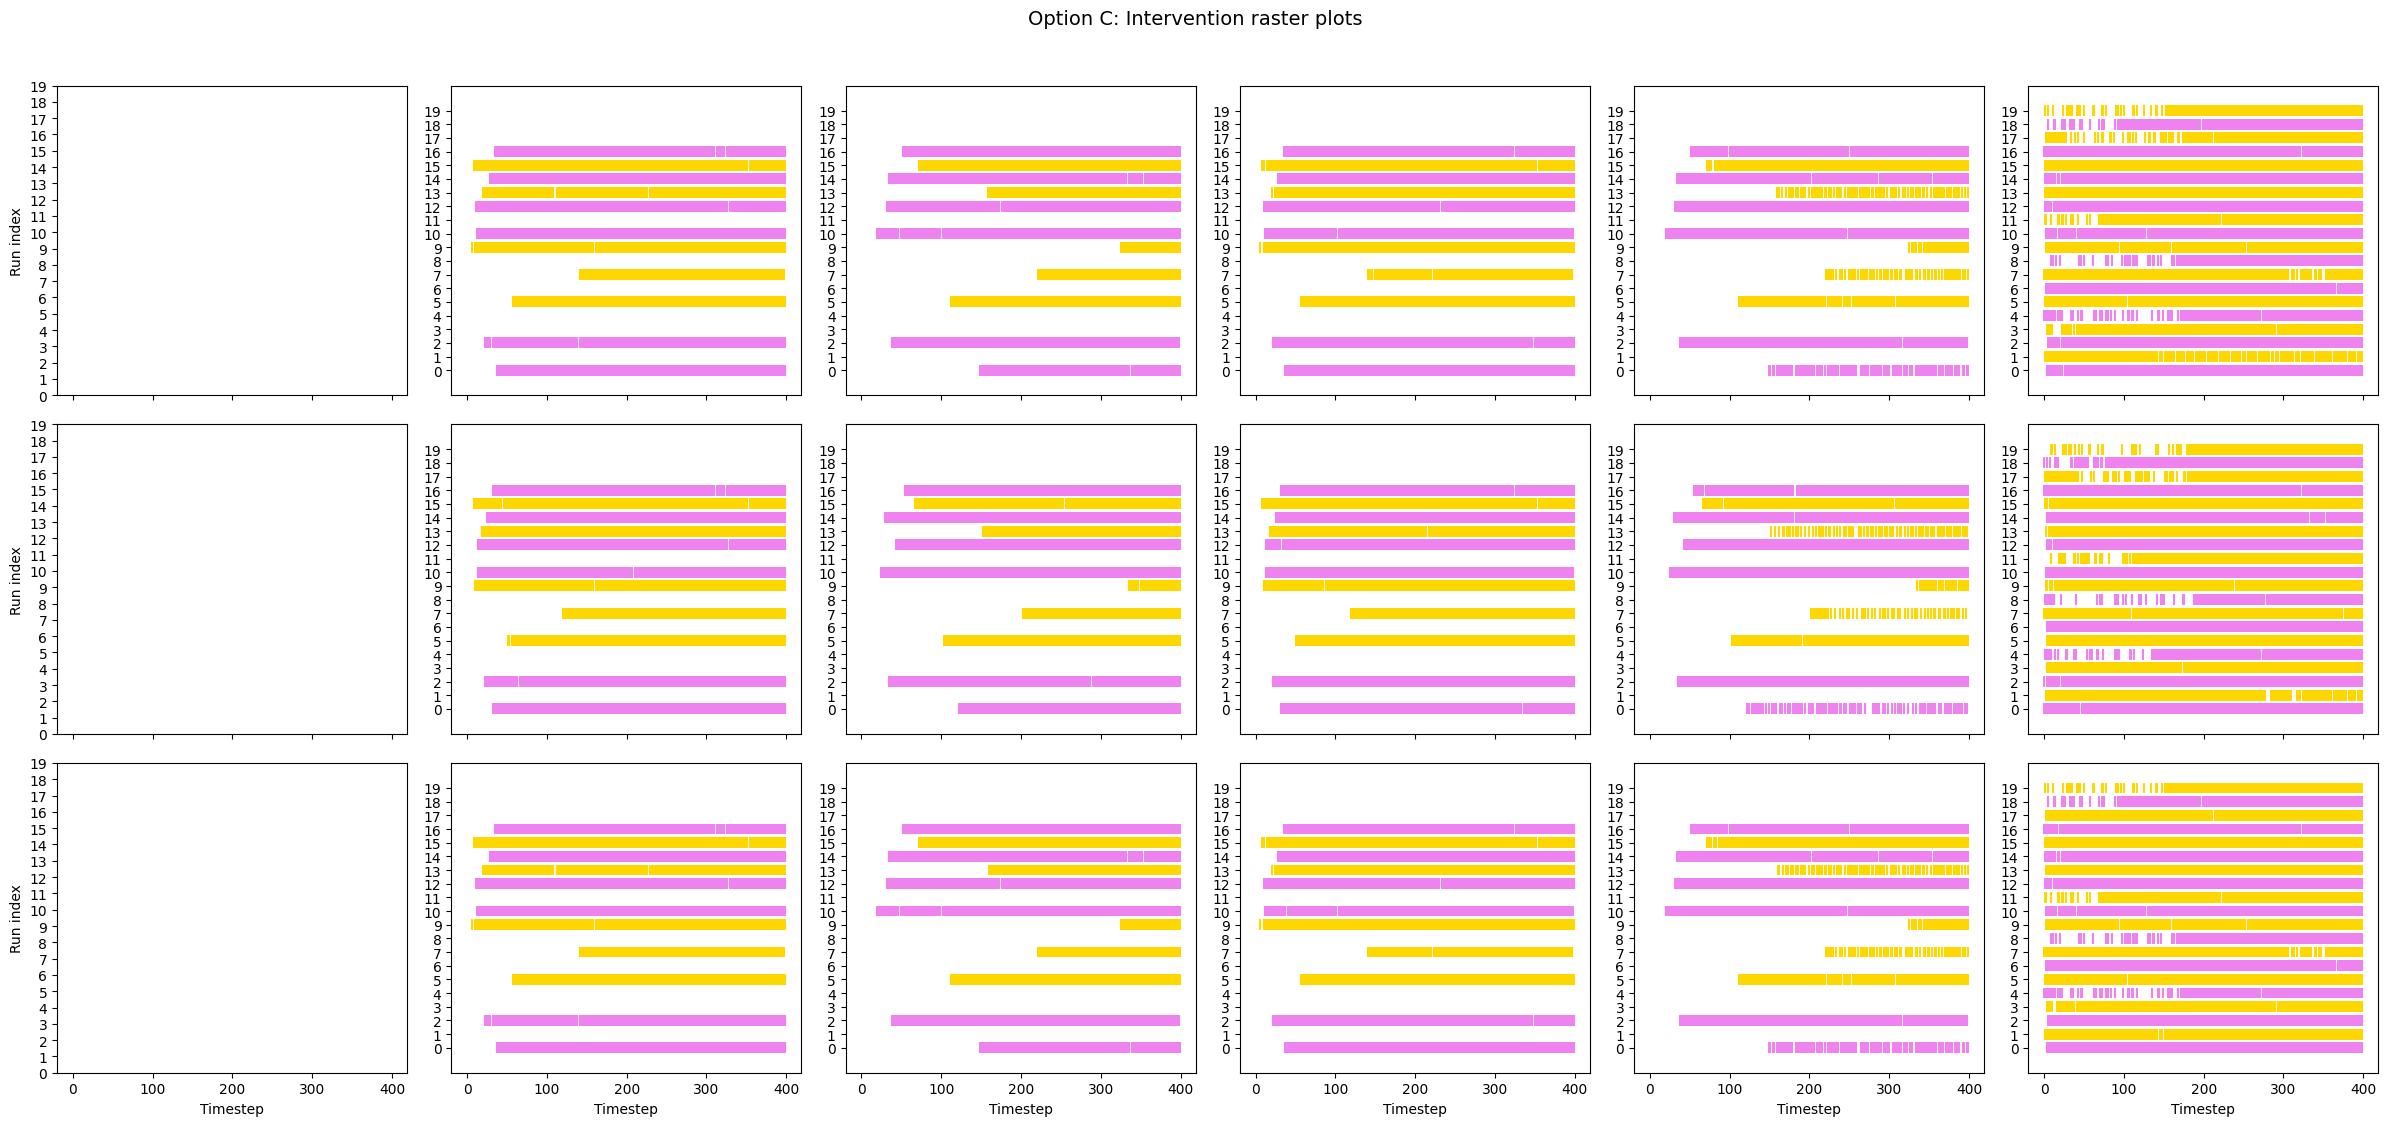

In [75]:
run_order_df = (intervention_summary_df[["run_id", "structure", "leader_style"]].drop_duplicates().sort_values(["structure", "leader_style", "run_id"]))

fig, axes = plt.subplots(len(structures), len(leader_styles), figsize=(24, 11), sharex=True, sharey=False)
for structure in structures:
    for leader_style in leader_styles:
        ax = get_ax(axes, structure, leader_style)

        runs_sub = run_order_df[(run_order_df["structure"] == structure) & (run_order_df["leader_style"] == leader_style)].reset_index(drop=True)
        raster_sub = intervention_raster_df[(intervention_raster_df["structure"] == structure) & (intervention_raster_df["leader_style"] == leader_style)]
        run_to_y = {run_id: i for i, run_id in enumerate(runs_sub["run_id"])}

        event_data = []
        colors = []
        for run_id, y_pos in run_to_y.items():
            run_events = raster_sub[raster_sub["run_id"] == run_id]
            event_data.append(run_events["time"].to_numpy())
            colors.append("violet" if y_pos % 2 == 0 else "gold")

        ax.eventplot(event_data, orientation="horizontal", colors=colors, lineoffsets=np.arange(len(event_data)), linelengths=0.8)
        ax.set_yticks(range(len(runs_sub)))

for ax in axes[-1, :]: ax.set_xlabel("Timestep")
for ax in axes[:, 0]: ax.set_ylabel("Run index")

fig.suptitle("Option C: Intervention raster plots", y=1.02, fontsize=14)
fig.tight_layout()
plt.show()

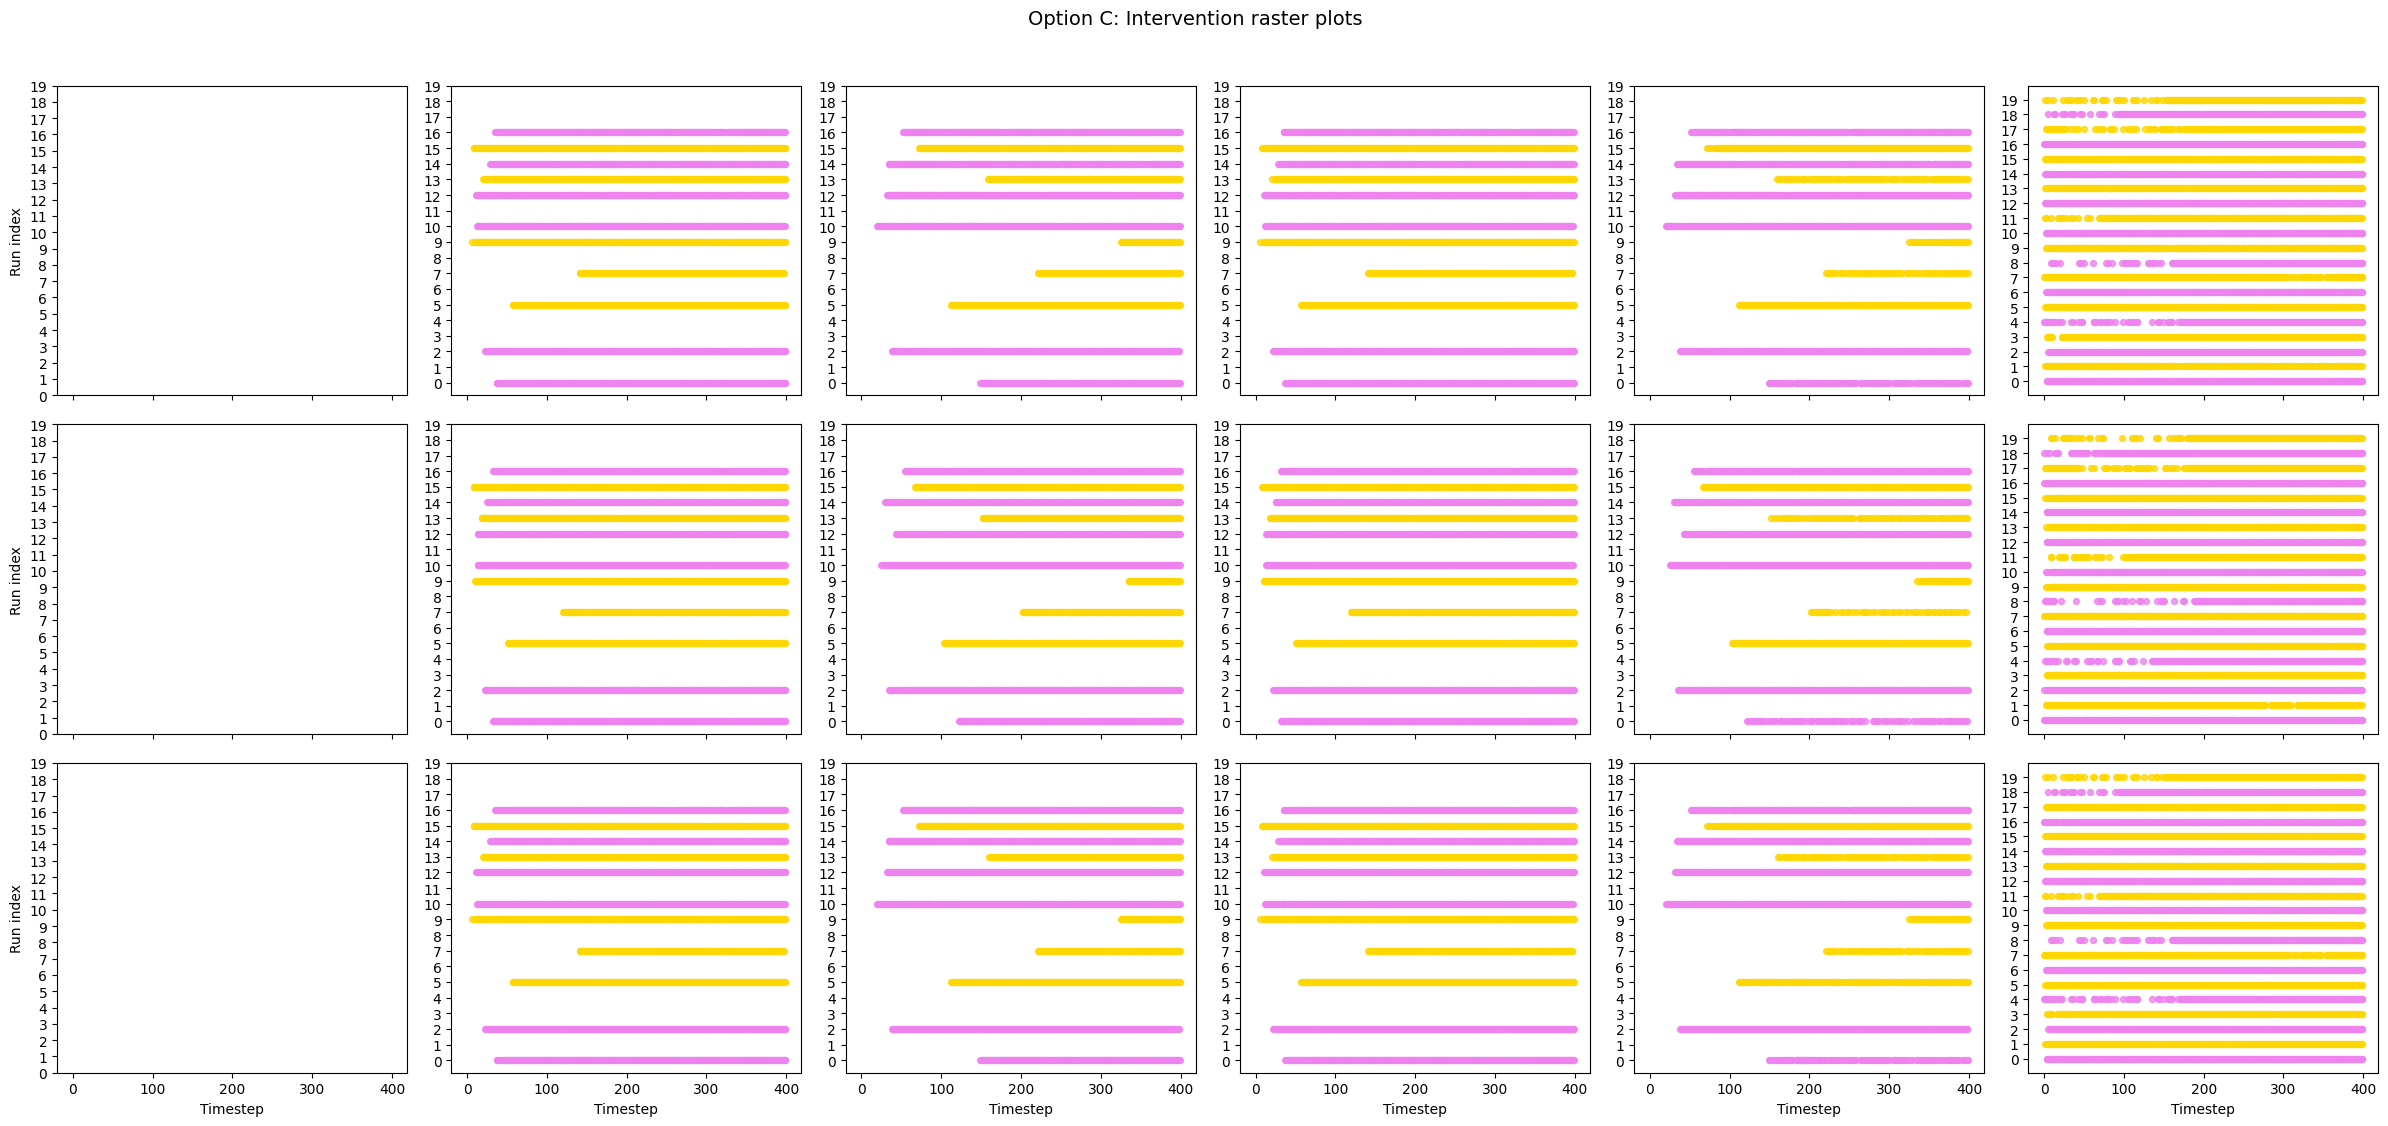

In [76]:
run_order_df = (intervention_summary_df[["run_id", "structure", "leader_style"]].drop_duplicates().sort_values(["structure", "leader_style", "run_id"]))

fig, axes = plt.subplots(len(structures), len(leader_styles), figsize=(24, 11), sharex=True, sharey=False)
for structure in structures:
    for leader_style in leader_styles:
        ax = get_ax(axes, structure, leader_style)

        runs_sub = run_order_df[(run_order_df["structure"] == structure) & (run_order_df["leader_style"] == leader_style)].reset_index(drop=True)
        raster_sub = intervention_raster_df[(intervention_raster_df["structure"] == structure) & (intervention_raster_df["leader_style"] == leader_style)]
        run_to_y = {run_id: i for i, run_id in enumerate(runs_sub["run_id"])}

        if not raster_sub.empty:
            for run_id, y_pos in run_to_y.items():

                run_events = raster_sub[raster_sub["run_id"] == run_id]

                if len(run_events) == 0:
                    continue

                x = run_events["time"].to_numpy()
                y = np.full(len(x), y_pos)

                color = "violet" if y_pos % 2 == 0 else "gold"

                ax.scatter(
                    x,
                    y,
                    marker="o",
                    s=18,
                    color=color,
                    alpha=0.8
                )

        ax.set_yticks(range(len(runs_sub)))

for ax in axes[-1, :]: ax.set_xlabel("Timestep")
for ax in axes[:, 0]: ax.set_ylabel("Run index")

fig.suptitle("Option C: Intervention raster plots", y=1.02, fontsize=14)
fig.tight_layout()
plt.show()

The below is interesting cause intervention pattern doesn't seem to have an effect, BUT, I believe the leaders all use the same intervention strength, which was definitely a factor in when we picked the different leaders during the RL-extension results. So, let me add that back in there tomorrow and we can have our leaders be flexible again by using varying strengths

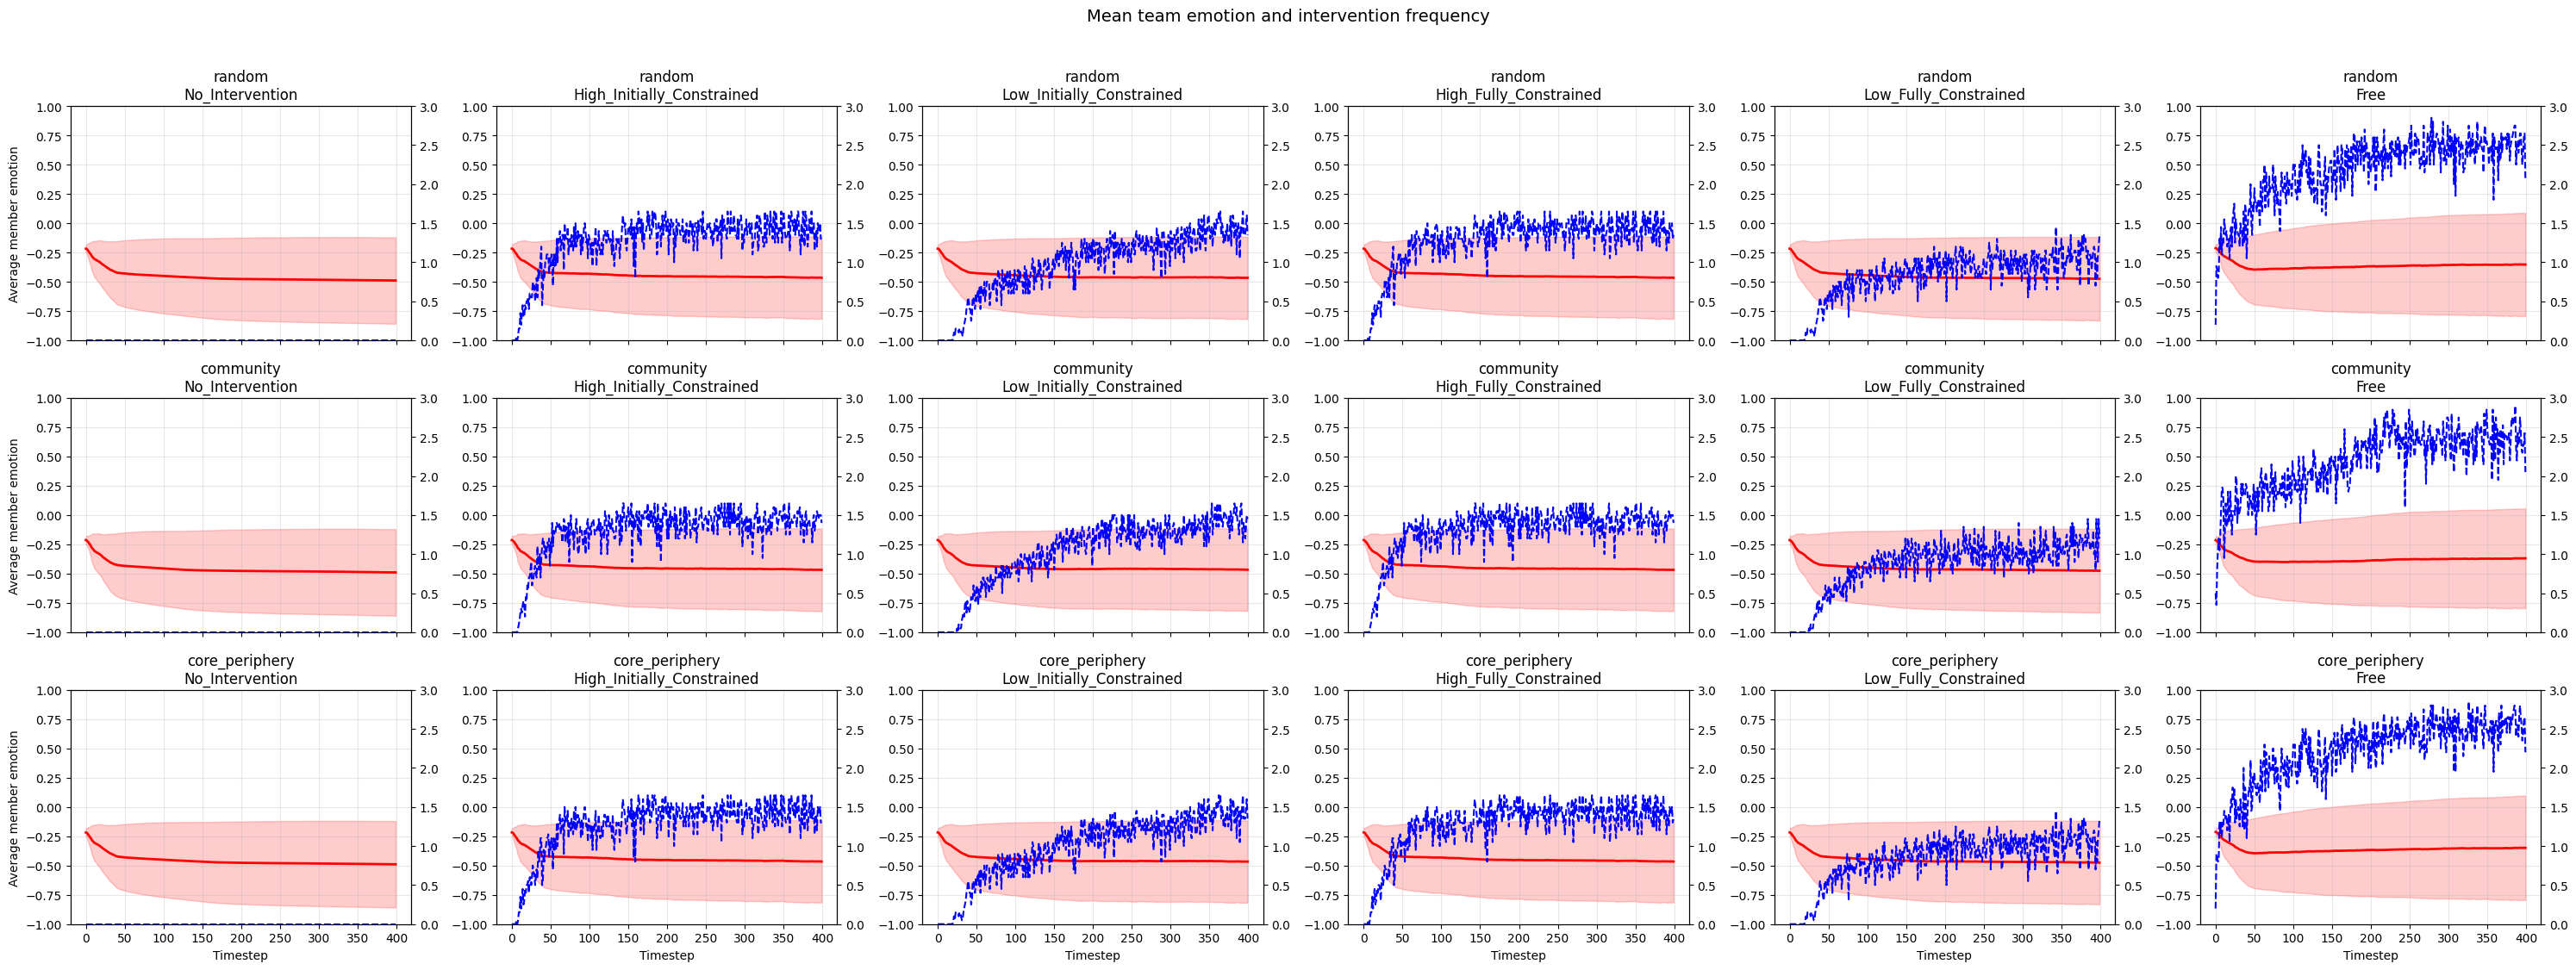

In [77]:
fig, axes = plt.subplots(len(structures), len(leader_styles), figsize=(30, 11), sharex=True, sharey=False)

for structure in structures:
    for leader_style in leader_styles:
        ax = get_ax(axes, structure, leader_style)

        emo = emotion_summary_df[(emotion_summary_df["structure"] == structure) & (emotion_summary_df["leader_style"] == leader_style)].sort_values("time")
        freq = freq_plot_df[(freq_plot_df["structure"] == structure) & (freq_plot_df["leader_style"] == leader_style)].sort_values("time")
        if not emo.empty:
            x = emo["time"].to_numpy()
            y = emo["mean_avg_member_emotion"].to_numpy()
            s = emo["sd_avg_member_emotion"].to_numpy()
            ax.plot(x, y, color="red", linewidth=2)
            ax.fill_between(x, y - s, y + s, color="red", alpha=0.2)

        ax2 = ax.twinx()
        if not freq.empty: ax2.plot(freq["time"], freq["mean_intervention_strength"], color="blue", linestyle="--", linewidth=1.5)
        ax2.set_ylim(0, 3)

        ax.set_title(format_condition_title(structure, leader_style))
        ax.set_ylim(-1, 1)
        ax.grid(True, alpha=0.3)

for ax in axes[-1, :]:  ax.set_xlabel("Timestep")
for ax in axes[:, 0]: ax.set_ylabel("Average member emotion")

fig.suptitle("Mean team emotion and intervention frequency", y=1.02, fontsize=14)
fig.tight_layout()
plt.show()

### RL Plots

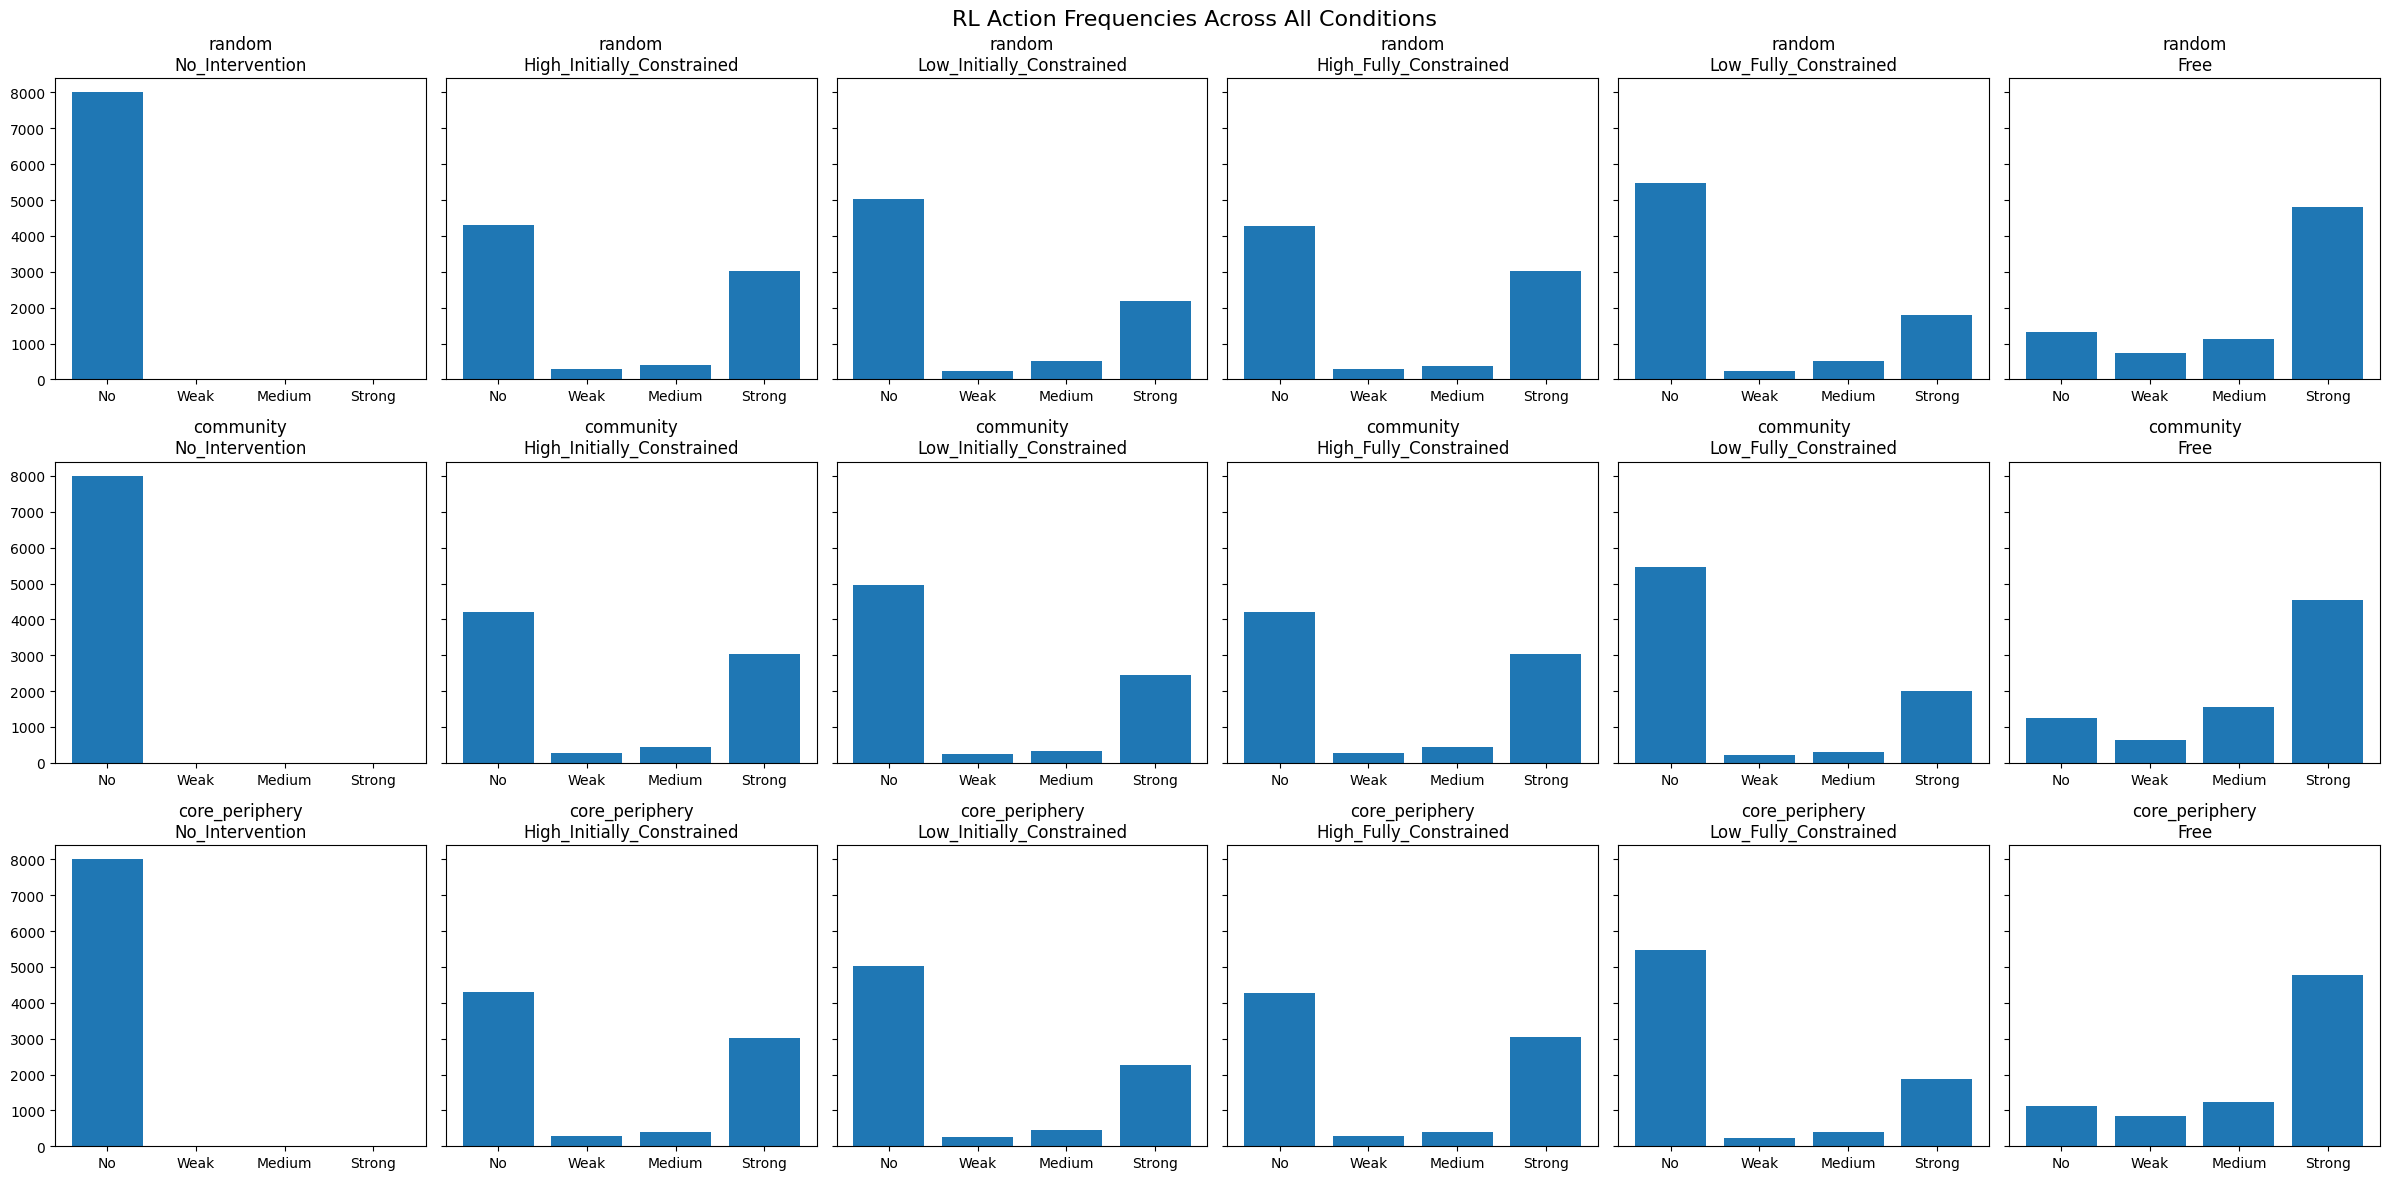

In [78]:
action_labels = {
    0: "No",
    1: "Weak",
    2: "Medium",
    3: "Strong"
}

fig, axes = plt.subplots(nrows=len(structures), ncols=len(leader_styles), figsize=(24, 12), sharey=True,)
for structure in structures:
    for leader_style in leader_styles:
        ax = get_ax(axes, structure, leader_style)
        sub = rl_action_df[(rl_action_df["structure"] == structure) & (rl_action_df["leader_style"] == leader_style)]

        if not sub.empty:
            counts = (sub["action"].map(action_labels).value_counts().reindex(["No", "Weak", "Medium", "Strong"]).fillna(0))
            ax.bar(counts.index, counts.values)
        else:
            ax.text(0.5, 0.5, "No RL data", ha="center", va="center")

        ax.set_title(format_condition_title(structure, leader_style))

plt.suptitle("RL Action Frequencies Across All Conditions", fontsize=16)
plt.tight_layout()
plt.show()

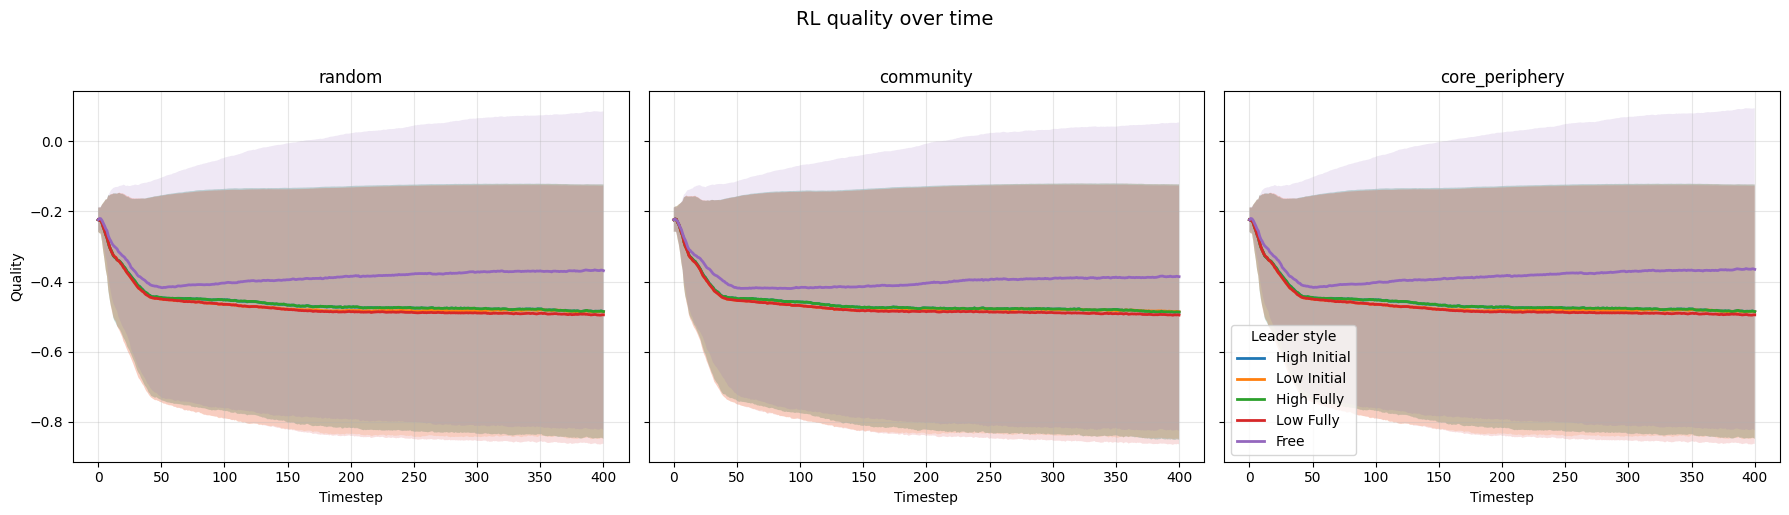

In [79]:
rl_quality_summary_df = (rl_quality_df.groupby(["structure", "leader_style", "time"], as_index=False).agg(mean_quality=("quality", "mean"), sd_quality=("quality", "std"), n_runs=("quality", "count")))
rl_quality_summary_df["sd_quality"] = (rl_quality_summary_df["sd_quality"].fillna(0.0))

fig, axes = plt.subplots(1, len(structures), figsize=(18, 5), sharey=True)

for i, structure in enumerate(structures):
    ax = axes[i]
    for leader_style in leader_styles:
        sub = rl_quality_summary_df[(rl_quality_summary_df["structure"] == structure) & (rl_quality_summary_df["leader_style"] == leader_style)].sort_values("time")
        if sub.empty:
            continue

        x = sub["time"].to_numpy()
        y = sub["mean_quality"].to_numpy()
        s = sub["sd_quality"].to_numpy()
        ax.plot( x, y, linewidth=2, label=styles_pretty.get(leader_style, leader_style))
        ax.fill_between(x, y - s, y + s, alpha=0.15)

    ax.set_title(structure)
    ax.grid(True, alpha=0.3)
    ax.set_xlabel("Timestep")

axes[0].set_ylabel("Quality")

axes[-1].legend(title="Leader style")

fig.suptitle("RL quality over time", y=1.02, fontsize=14)
fig.tight_layout()
plt.show()

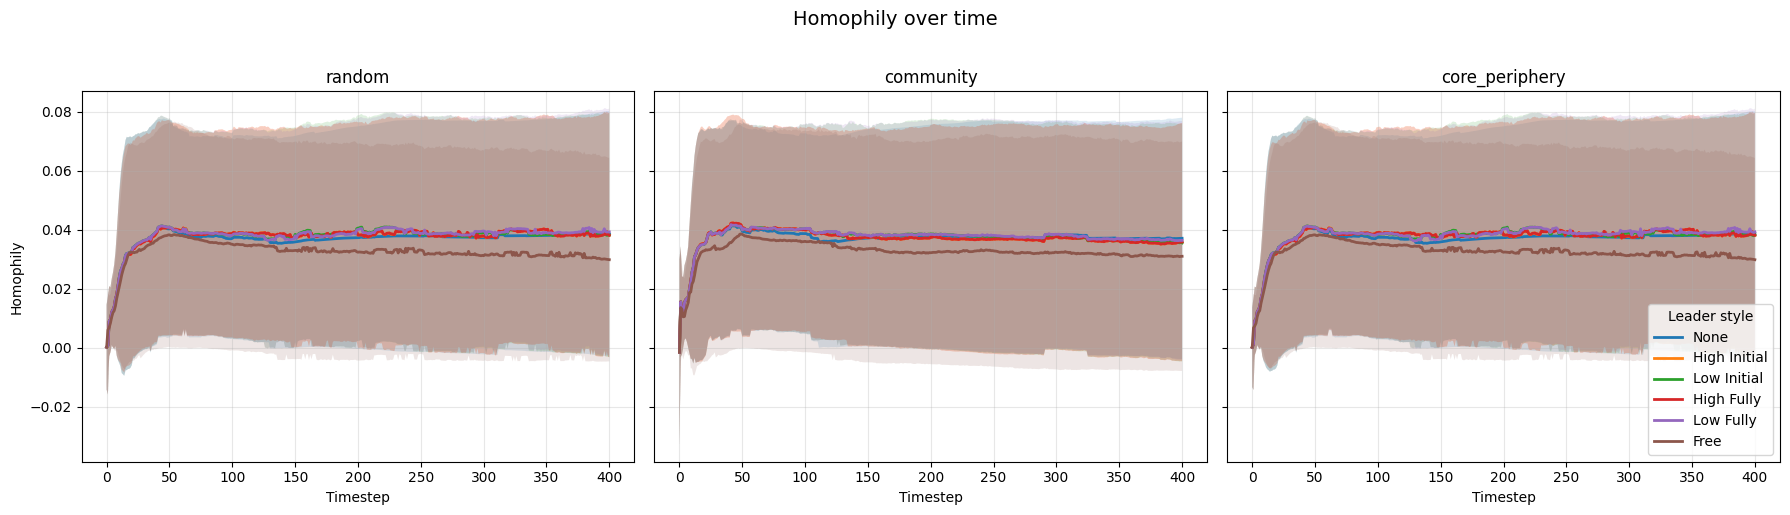

In [80]:
homophily_summary_df = (homophily_df.groupby(["structure", "leader_style", "time"], as_index=False).agg(mean_homophily=("homophily", "mean"), sd_homophily=("homophily", "std"), n_runs=("homophily", "count")))
homophily_summary_df["sd_homophily"] = homophily_summary_df["sd_homophily"].fillna(0.0)

fig, axes = plt.subplots(1, len(structures), figsize=(18, 5), sharey=True)

for i, structure in enumerate(structures):
    ax = axes[i]
    for leader_style in leader_styles:
        sub = homophily_summary_df[(homophily_summary_df["structure"] == structure) & (homophily_summary_df["leader_style"] == leader_style)].sort_values("time")
        if sub.empty:
            continue

        x = sub["time"].to_numpy()
        y = sub["mean_homophily"].to_numpy()
        s = sub["sd_homophily"].to_numpy()

        ax.plot(x, y, linewidth=2, label=styles_pretty.get(leader_style, leader_style))
        ax.fill_between(x, y - s, y + s, alpha=0.15)

    ax.set_title(structure)
    ax.grid(True, alpha=0.3)
    ax.set_xlabel("Timestep")

axes[0].set_ylabel("Homophily")

axes[-1].legend(title="Leader style")

fig.suptitle("Homophily over time", y=1.02, fontsize=14)
fig.tight_layout()
plt.show()

In [81]:
rows = []
for results in results_list:
    final_avg_emotion = (results.avg_emotion_history[-1] if len(results.avg_emotion_history) > 0 else np.nan)
    mean_quality = (np.mean(results.rl_quality) if results.rl_quality is not None and len(results.rl_quality) > 0 else np.nan)
    final_homophily = (results.homophily_history[-1] if results.homophily_history is not None and len(results.homophily_history) > 0 else np.nan)
    rows.append({
        "run_id": results.run_id,
        "seed": results.seed,
        "structure": results.metadata.get("structure"),
        "leader_style": results.metadata.get("leader_style"),
        "final_avg_emotion": final_avg_emotion,
        "mean_quality": mean_quality,
        "final_homophily": final_homophily,
    })

summary_runs_df = pd.DataFrame(rows)
summary_df = (summary_runs_df.groupby(["structure", "leader_style"], as_index=False)
    .agg(
        mean_final_avg_emotion=("final_avg_emotion", "mean"),
        sd_final_avg_emotion=("final_avg_emotion", "std"),
        mean_quality=("mean_quality", "mean"),
        sd_quality=("mean_quality", "std"),
        mean_final_homophily=("final_homophily", "mean"),
        sd_final_homophily=("final_homophily", "std"),
        n_runs=("run_id", "count"),
    )
)

display(summary_df)

,structure,leader_style,mean_final_avg_emotion,sd_final_avg_emotion,mean_quality,sd_quality,mean_final_homophily,sd_final_homophily,n_runs
0,community,Free,-0.369280,0.426249,-0.394430,0.367220,0.031015,0.038850,20
1,community,High_Fully_Constrained,-0.467347,0.352970,-0.460142,0.319631,0.035849,0.040347,20
2,community,High_Initially_Constrained,-0.467347,0.352970,-0.460142,0.319631,0.035849,0.040347,20
3,community,Low_Fully_Constrained,-0.475620,0.357612,-0.468958,0.324995,0.036395,0.040429,20
4,community,Low_Initially_Constrained,-0.466944,0.352520,-0.464285,0.322152,0.035548,0.040188,20
5,community,No_Intervention,-0.489745,0.369824,NaN,NaN,0.037117,0.040866,20
6,core_periphery,Free,-0.349298,0.446256,-0.378461,0.379117,0.029864,0.034481,20
7,core_periphery,High_Fully_Constrained,-0.466131,0.351204,-0.457125,0.317929,0.038157,0.041374,20
8,core_periphery,High_Initially_Constrained,-0.466109,0.351193,-0.457253,0.318001,0.038164,0.041376,20
9,core_periphery,Low_Fully_Constrained,-0.474933,0.356325,-0.467816,0.324535,0.039285,0.041794,20
